In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller


# Задание 1. ACF вручную (passengers, lag 1–50)

In [2]:
passengers = pd.read_csv("passengers.csv")  # колонка может называться Passengers
ts = passengers.iloc[:, 1]  # если в первом столбце дата
ts = ts.astype(float)


In [3]:
def manual_acf(series, max_lag):
    acf_values = []
    series = series - series.mean()
    denom = np.sum(series ** 2)

    for lag in range(1, max_lag + 1):
        shifted = series.shift(lag)
        num = np.sum(series[lag:] * shifted[lag:])
        acf_values.append(num / denom)

    return acf_values


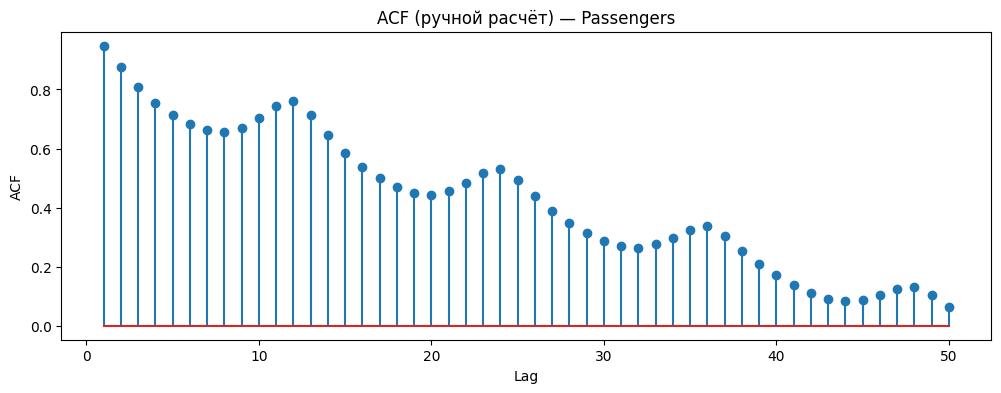

In [4]:
lags = 50
acf_manual = manual_acf(ts, lags)

plt.figure(figsize=(12,4))
plt.stem(range(1, lags+1), acf_manual)
plt.title("ACF (ручной расчёт) — Passengers")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()


# Задание 2. ACF через plot_acf (passengers)

<Figure size 1800x1000 with 0 Axes>

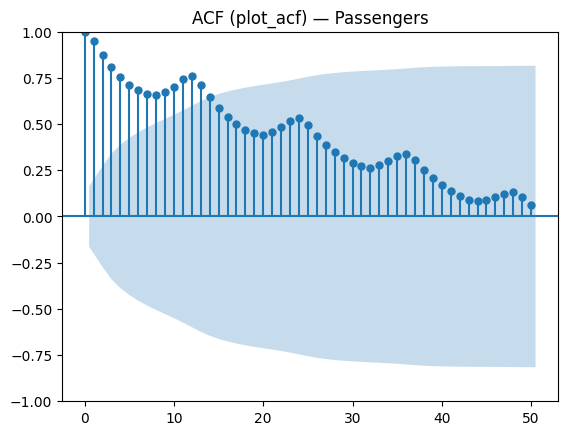

In [7]:
plt.figure(figsize=(18,10))
plot_acf(ts, lags=50)
plt.title("ACF (plot_acf) — Passengers")
plt.show()


Графики очень похожи, но:

* plot_acf отображает доверительные интервалы (синие границы),
* ручной график — только значения

# Задание 3. То же самое для датасета births

In [8]:
births = pd.read_csv("births.csv")
ts_b = births.iloc[:, 1].astype(float)


Ручной ACF

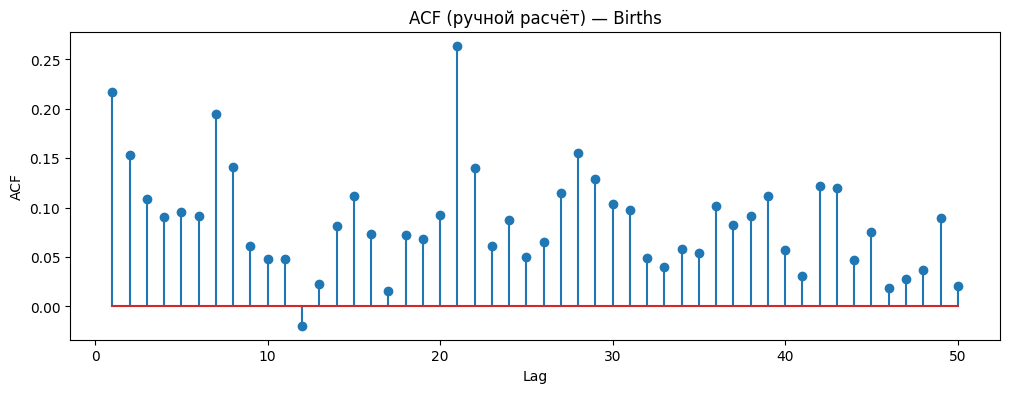

In [9]:
acf_manual_b = manual_acf(ts_b, 50)

plt.figure(figsize=(12,4))
plt.stem(range(1, 51), acf_manual_b)
plt.title("ACF (ручной расчёт) — Births")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()


ACF через plot_acf

<Figure size 1200x400 with 0 Axes>

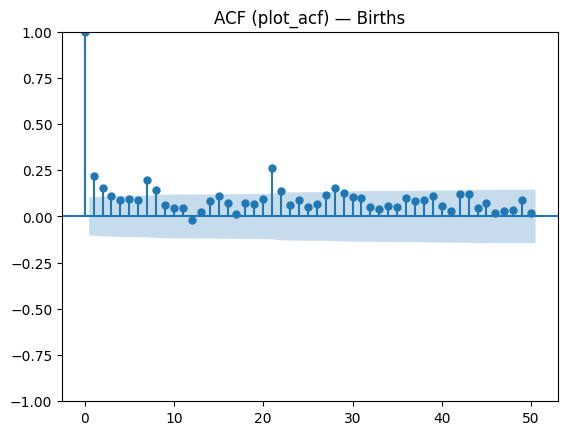

In [10]:
plt.figure(figsize=(12,4))
plot_acf(ts_b, lags=50)
plt.title("ACF (plot_acf) — Births")
plt.show()


# Задание 4. ACF функции sin(x), 100 лагов

Построить sin(x)

In [11]:
x = np.arange(0, 50, 0.1)
sin_ts = pd.Series(np.sin(x))


Ручной ACF (100 лагов)

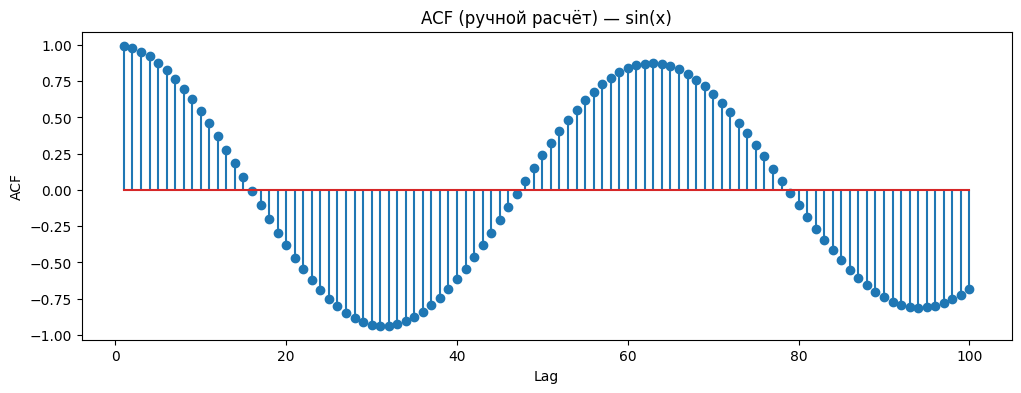

In [12]:
acf_sin = manual_acf(sin_ts, 100)

plt.figure(figsize=(12,4))
plt.stem(range(1, 101), acf_sin)
plt.title("ACF (ручной расчёт) — sin(x)")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()


ACF через plot_acf

<Figure size 1.11e+06x400 with 0 Axes>

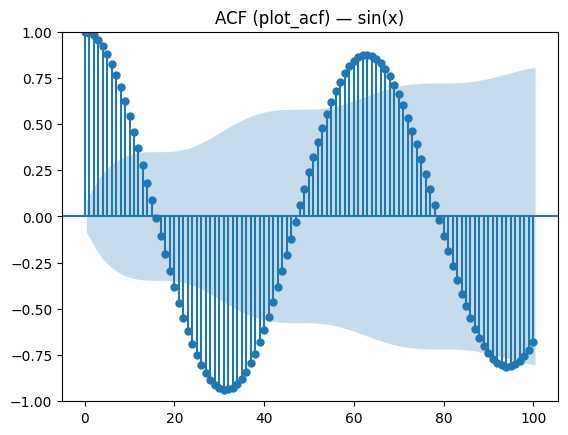

In [17]:
plt.figure(figsize=(11100,4))
plot_acf(sin_ts, lags=100)
plt.title("ACF (plot_acf) — sin(x)")
plt.show()


# Задание 5. Тест Дики–Фуллера (ADF) для births

In [ ]:
result = adfuller(ts_b)
print("ADF statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"Critical value {key}: {value}")

adf_stat = result[0]
p_value = result[1]
crit = result[4]

print("========================== Тест Дики–Фуллера (ADF) для ряда births =================================")

print(f"ADF statistic: {adf_stat:.6f}")
print(f"p-value: {p_value:.10f}")
print("\nКритические значения:")
for key, value in crit.items():
    print(f"  {key}: {value:.6f}")

print("\n========================= Интерпретация ================================================================")

if p_value < 0.05:
    print("p-value < 0.05 → отвергаем нулевую гипотезу о наличии единичного корня.")
    print("Следовательно, временной ряд можно считать *стационарным*")
else:
    print("p-value ≥ 0.05 → нет оснований отвергать нулевую гипотезу.")
    print("Следовательно, временной ряд *не является стационарным*")

print("\nСравнение ADF statistic с критическими значениями:")
if adf_stat < crit["1%"]:
    print("ADF statistic < критического значения на уровне 1% → сильные доказательства стационарности")
elif adf_stat < crit["5%"]:
    print("ADF statistic < критического значения на уровне 5% → умеренные доказательства стационарности")
elif adf_stat < crit["10%"]:
    print("ADF statistic < критического значения на уровне 10% → слабые доказательства стационарности")
else:
    print("ADF statistic > всех критических значений → ряд нестационарный")

print("\nИТОГ: ряд births можно считать стационарным,")
print("так как и p-value очень мало, и статистика ADF значительно меньше критических значений")


ADF statistic: -4.808291253559765
p-value: 5.2434129901498554e-05
Critical value 1%: -3.448748905151901
Critical value 5%: -2.8696473721448728
Critical value 10%: -2.5710891239349585
========================== Тест Дики–Фуллера (ADF) для ряда births =================================
ADF statistic: -4.808291
p-value: 0.0000524341

Критические значения:
  1%: -3.448749
  5%: -2.869647
  10%: -2.571089

========================= Интерпретация ================================================================
p-value < 0.05 → отвергаем нулевую гипотезу о наличии единичного корня.
Следовательно, временной ряд можно считать *стационарным*

Сравнение ADF statistic с критическими значениями:
ADF statistic < критического значения на уровне 1% → сильные доказательства стационарности.

ИТОГ: ряд births можно считать стационарным,
так как и p-value очень мало, и статистика ADF значительно меньше критических значений.
